In [24]:
## Importing relevant packages 

import numpy as np
import pandas as pd
import re
from datetime import datetime
import string
from collections import defaultdict
from tqdm import tqdm
from bs4 import BeautifulSoup
import ijson
import json
from langdetect import detect
import langid
from collections import Counter
from itertools import chain

#Importing NLTK and NLP packages for preprocessing

import nltk
from nltk.tokenize import word_tokenize


#Importing packages for data visualization 

import matplotlib.pyplot as plt
import seaborn as sns

#import gensim.downloader

# for Word2Vec and procrucstes alignment
import gensim
from gensim.models import Word2Vec
from scipy.linalg import orthogonal_procrustes
from scipy.spatial.distance import cosine
from sklearn.metrics.pairwise import cosine_similarity

from tqdm import tqdm
from tqdm.notebook import tqdm  # or tqdm.auto if not using Jupyter
tqdm.pandas()  # <-- enables progress_apply


In [2]:
## Functions

# 1. Function to join phrases that have space in the text with _ to be considered as one token

def join_phrases(text, phrase_map):
    for phrase, joined in sorted(phrase_map.items(), key=lambda x: -len(x[0])):  # longest first
        text = text.replace(phrase, joined)
    return text


# 2. Preprocessing function

def preprocess(text):
    
    # Remove html staff
    
    def strip_html(text):
        return BeautifulSoup(text, "html.parser").get_text()
    
    text = strip_html(text)
    
    # Lowercasing words
    text = text.lower()
    
    # Join phrases
    text = join_phrases(text, phrase_map)
    
    # Removing '&amp'
    text = re.sub(r'&amp',' ', text)
    
    # Replace other instances of "&" with "and"
    text = re.sub(r'&','and', text)
    
    # Removing mentions 
    text = re.sub(r'@\w+ ', ' ', text)
    
    # Removing 'RT' and 'via'
    text = re.sub(r'(^rt|^via)((?:\b\W*@\w+)+): ', ' ', text)
    
    # Removing <p> and </p> HTML tags
    
    text = re.sub(r'</?p>', ' ', text)
    
    # Removing punctuation
    # Using the module string to define what punctuation we want removed
    my_punctuation = string.punctuation.replace('#', '').replace('-', '').replace('_', '') # We don't want "#", "-" or "_" removed  
    my_punctuation = my_punctuation+'’“”—'  # Adding additional punctuation that is not captured by string.punctuation 
    
    text = text.translate(str.maketrans({p: ' ' for p in my_punctuation}))

    # Removing odd special characters 
    text = re.sub(r' - ',' ', text) #removing dash lines bounded by whitespace (and therefore not part of a word)
    text = re.sub(r"[┻┃━┳┓┏┛┗]"," ", text)
    text = re.sub(r"\u202F|\u2069|\u200d|\u2066|\u2060|\u2063", " ", text)
    text = re.sub(r"‘"," ", text)
    text = re.sub(r"•"," ", text)
    text = re.sub(r"・・・"," ", text)
    text = re.sub(r"…"," ", text)
    
    # Removing URLs
    text = re.sub(r'http\S+', ' ', text)
    
    # Removing numbers
    text = re.sub(r'[0-9]',' ', text)
    
    # Removing \n
    text = re.sub(r'\n+', ' ', text)
    
    # Remove hashtags
    text = re.sub(r'#\w+', ' ', text)
    
    # Removing whitespace
    
    text = re.sub(r'\s+', ' ', text).strip()
    
    
    return text

# 3. Function to remove non-english posts

def is_english(text):
    lang, _ = langid.classify(text)
    return lang == 'en'


### Netnography dictionary

In [3]:
# Dictionary of terms relating to 
# identities
# oppression systems
# intersectionality-femininism related concepts 

identity_axes =  {"gender": ["gender", "woman","women", "man", "men", "female", "male", "girl", "boy", "trans", "trans*", "transgender", "transwoman", "transwomen",
              "transmasc", "transfem", "transmasculine", "transfeminine", "cis","nonbinary", "non-binary", "nb", "lgbtq", "sex", "sexes", "androgynous", "binaries", "binary", "lgbt", 
               "queer", "cis passing", "cisgender", "feminine", "femininity", "femboy", "femme", "gc", "gender conforming", "lgbtqa", "quiltbag",
              "gender fluid", "genderfluid", "gender-nonconformity", "gender non conforming", "gender nonconforming",
              "genderqueer", "gender-queer", "gnc", "lgbtqia+", "lgbtq+", "intersex", "masculine", "masculinity", "queerness", "transness", "afab",
          "non-cis", "agender", "amab", "bigender"],

    
    "sexuality": ["sexuality", "lgbtq", "a-spec", "ace","aro", "allosexual", "aromantic", "biromantic","asexual", "asexuality", "bi", "lesbian","gay",
                  "bisexual", "bisexuality", "het", "lgbt", "lgtbtq", "queer", "butch", "hetero", "heterosexual", "heterosexuality",
                  "homosexuality", "lgbtqia+", "lgbtq+", "quiltbag", "pansexual", "pansexuality", "pan", "poly", "polyamory", "queerness", "wlw", "mlm",
                 "demisexual", "demisexuality", "heteroromantic", "panromantic", "aromanticism", "allo", "non-ace", "monogamous", "polysexual", "non-monogamous"],


    "race_ethnicity": ["race", "ethnicities", "ethnicity","black", "white", "of color", "of colour", "bipoc", "poc", "woc","asian",
                       "latinx", "latino", "latina", "indigenous", "api", "indian", "western", "african", "african american", "american", 
                       "american asian", "american indian", "brown", "immigrant","blackness", "caribbean",
                       "caucasian", "color", "colour", "color skin", "colour skin", "skin color", "skin colour",
                       "ethnic", "g*psy", "hispanic", "immigration", "interracial", "light-skinned", "mexican",
                       "middle eastern", "moc", "multicultural", "multiracial", "native american", "native", "non-black",
                       "pakistani", "qpoc", "qtpoc", "twoc", "racial", "romani", "whiteness", "white skin", "jew", "jews",
                      "biracials", "non-white", "white-passing", "arab", "aboriginal", "chicana"],

    
    "class": ["class", "affluent", "rich", "poor","upper middle class","economic","economic disadvantage", "economically privileged",
             "elite", "employed", "employment", "working class", "socioeconomic","homeless", "homelessness", "impoverished",
             "industrial workers", "SES", "income", "middle class", "middle-class", "upper class", "upper-class", "millionaire", "poverty", "sex work", "sex worker",
             "underpaid",  "wealth", "wealthy", "underemployed", "low-income", "labor"],

    "religion": ["religion", "religious", "muslim", "jewish", "christian","christianity", "atheism", "burqua", "hijab", "islam",
            "catholic", "orthodox"],

    
    "ability": ["ability", "disability", "disabilities", "abled", "able bodied", "able bodied-ness", "able-bodied", 
                "adhd", "autism", "autistic", "disabled", "chronic illness", "deaf", "depression", "eating disorders",
                "mental health", "mentally ill", "mental illness", "mental disorder", "neuroatypical", "neurodivergence",
                "neurodivergent", "neurodiversity", "neurotypical","wheelchair", "anxiety", "bipolar", "schizophrenia",
           "psychotic"],
                
    "age": ["age", "elderly", "youth", "old", "older","young", "younger", "teenage"],
    
    "body": ["body", "bodies", "body size", "fat", "fatness","obese", "obesity", "overweight", "thin", "weight", "thinness", "body_positivity", "skinny", "curvy"],
    
    "vegans" : ["animals", "animal", "vegan", "vegans", "species", "veganism", "vegeterian", "plant-based", "non-human"] 
           
}

systems_of_oppression = {
    "racism": ["racism", "racist", "anti-racist", "antiracism", "white supremacy", "white supremacist", "colorism", "colourism", "whitewashed", "whitewash", "eurocentrism", "anti-blackness", "anti-black", "antisemitism", "anti semitic"],
    
    "sexism_patriarchy": ["sexism", "sexist", "patriarchy", "misogyny", "androcentric", "cat call", "cat calling", "domestic violence",
               "gender-based violence", "hypersexualization", "hypersexualized", "intimate partner violence", "male gaze",
               "misogynist", "misogynistic", "misogynoir", "over-sexualised", "sexualised", "sexualisation", "patriarchical", "rape culture",
              "sexualized", "sexualization", "slut shaming", "heterosexism", "heteropatriarchy", "rape", "sexual assault"],
    
    "ableism": ["ableism", "ableist"],
    
    "heteronormativity_cissexism": ["homophobia","cissexism", "homophobic", "acephobe", "acephobia", "aphobia", "biphobic", "biphobia","heteronormative", "heteronormativity", "anti lgbt", "anti-queerness", "anti-aceness", "amatonormativity", "queerphobia, transphobia", "transphobic", "transphobes", "transmisogyny", "transmisogynistic", "anti trans", "transmisandry", "transandrophobia"],
    
    "ageism": ["ageism", "ageist"],
    
    "capitalism": ["capitalism", "capitalist","capitalistic", "consumerist", "corporations", "neoliberal", "neoliberalism", "liberalism", "marxism", "marxist", "marx", "anarchism", "anarchist", "foucault", "socialism",  "socialist", "engels", "anti-capitalist", "materialism", "materialist", "individualism", "decomodification", "commodification"],
    
    "classism" : ["classism", "class struggle", "classed", "classist"],
    
    "colonialism": ["colonial", "colonialism", "colonialist", "colonization", "colonizer","imperialism", "settler states", "settler colonialism", "apartheid", "post-colonial", "abolitionism", "abolitionist", "postcolonial"],
    
    "religious discrimination": ["islamophobia","islamophobic"],
    
    "sizeism": ["fatphobia", "fat antagonism", "fat phobia", "fat shaming", "thin shaming"], 
    
    "speciesism": ["speciesism", "human supremacy"],
    
    "kyriarchy": ["kyriarchy"],
    
    "general" : ["oppression", "oppressions", "oppressive", "oppressing", "oppressed", "oppressor", "erasure", "erased", "exploitation", 
                      "abuse", "abused", "abuser", "abusive", "bias", "biases", "bigotry", "bigot", "bigoted", "difference", 
                      "privilege", "privileges", "control", "dehumanisation", "dehumanizing", "discriminate", "discriminated", "discriminating", 
                      "discrimination", "discriminatory", "disempowered", "disempowering", "dominance", "dominant", "dominate", 
                      "dominating", "domination", "exclude", "exclusion", "exclusionist", "exploit", "exploitative", "exploited", "exploiting",
                      "shaming", "fetishized", "hierarchy", "inequality", "inequalities", "stereotyping", "stereotype", "harassment", "hate", "hegemonic",
                      "hegemony", "hierarchical", "supremacists", "supremacy", "humiliation", "inequities", "injustice",
                      "institutional", "institutionalized", "interlocking", "power structures", "microaggression",
                      "normativity", "normative", "objectification", "objectified", "objectify", "objectifying", "othering",
                      "pay gaps", "wage gap", "police brutality", "police violence", "systemic power", "prejudice", "profit",
                     "stigma", "stigmatized", "subjugation", "subordination", "suppress", "suppressed", "underprivileged", "underrepresented",
                      "universalism", "victimization", "supremacist", "minorities", "minority", "marginalized"] 

}


intersectionality_concepts = [
    "intersectionality", "intersectional", "intersectionalism", "intersectional feminism", "hierarchy of oppression", "intersect", "intersecting",
    "interlocking systems of oppression", "systems of oppression", "intersecting identities", "bell hooks", "kimberlé crenshaw", "crenshaw", "patricia hill collins", "kimberle crenshaw",
    "audre lorde", "angela davis", "judith butler", "axes of oppression", "intersecting oppressions", "multiple identities", "social identities", "white feminist", "black feminist",
    "intersectional feminist", "womanism", "radical feminism", "liberal feminism", "white feminism", "black feminism", "radical feminst", "liberal feminist", "oppression olympics",
    "identity politics", "critical race theory", "critical theory", "black feminist thought"

]

### Loading the data

In [4]:
## Importing data
df = pd.read_json("intersectionality_matches.json")


In [5]:
len(df)

46486

Here I remove 1523 posts by certain antifemist profile to avoid biasing the results since they are a substantial amount.

In [6]:
df['post_url'].str.contains('ultramaga', case=False, na=False).sum()

1523

In [8]:
df = df[~df['post_url'].str.contains('ultramaga', case=False, na=False)]

In [9]:
len(df)

44963

### Preprocessing and data preparation steps

In [10]:
## Create a new column with year

# Ensure 'date' is in datetime format

df['date'] = pd.to_datetime(df['date'])

# Extract year from the date column

df['year'] = df['date'].dt.year

## Redefining dataset to only include useful columns 
df = df[['id', 'post_url','type','date', 'tags', 'year','text', 'body', 'answer', 'question', 'excerpt', 'description', 'caption']]


In [11]:
## Create a new column that will include content from all post types

df['content'] = np.select(
    [
        df['type'] == 'text',
        df['type'] == 'link',
        df['type'] == 'photo',
        df['type'] == 'video',
        df['type'] == 'quote',
        df['type'] == 'answer',
        df['type'] == 'chat',
        df['type'] == 'audio'
        
        
    ],
    [
        df['body'],
        df['excerpt'].fillna('') + ' ' + df['description'].fillna(''),
        df['caption'],
        df['caption'],
        df['text'],
        df['question'].fillna('') + ' ' + df['answer'].fillna(''),
        df['body'],
        df['caption']
        
        
    ],
    default=''
)

In [15]:
## Join phrases of interest from the dictionary so that they are considered as one token in the Word2Vec

# Combine all curated keywords into a single list

curated_keywords = list(set(
    list(chain.from_iterable(identity_axes.values())) +
    list(chain.from_iterable(systems_of_oppression.values())) +
    intersectionality_concepts
))

# Select only the phrases

known_phrases = list(set([
    phrase for phrase in curated_keywords
    if " " in phrase  # Only multi-word ones
]))

# Make a mapping of phrases with space and replaced with _, this is to be used in pre-processing
phrase_map = {phrase: phrase.replace(" ", "_") for phrase in known_phrases}


In [16]:
## Preprocessing text: You can get a progress bar by importing tqdm and using progress_apply instead of apply

df['content_cleaned']= df['content'].progress_apply(lambda x:preprocess(x))


  0%|          | 0/44963 [00:00<?, ?it/s]

/var/folders/d2/kpt7pw250sqd29ntmg5b6p8c0000gn/T/ipykernel_97982/111505053.py:18: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  return BeautifulSoup(text, "html.parser").get_text()


In [17]:
## Remove non-english posts

df['is_english'] = df['content_cleaned'].apply(is_english)

df = df[df['is_english']]


In [18]:
## Remove empty posts

df = df[df['content_cleaned'].str.strip() != '']


In [19]:
## Tokenize text

df['tokenize']= df['content_cleaned'].progress_apply(lambda x:word_tokenize(x))


  0%|          | 0/39504 [00:00<?, ?it/s]

In [20]:
## Count number of total tokens and unique words for each year

# Unique words

# Dictionary to store vocabulary sizes by year
vocab_sizes_by_year = {}

# Group dataframe by year

for year, group in df.groupby('year'):
    # Flattening all tokens for this year
    all_tokens = [token for tokens in group['tokenize'] for token in tokens]
    
    # Building frequency counter
    word_counts = Counter(all_tokens)
    
    # Gettting vocabulary size
    vocab_size = len(word_counts)
    
    # Save to dictionary
    vocab_sizes_by_year[year] = vocab_size


for year, vocab_size in sorted(vocab_sizes_by_year.items()):
    print(f"{year}: {vocab_size} unique words")
    
# Total tokens

token_counts_per_year = df.groupby('year')['tokenize'].apply(lambda posts: sum(len(tokens) for tokens in posts))
print(token_counts_per_year)


2013: 41021 unique words
2014: 44532 unique words
2015: 48187 unique words
2016: 45523 unique words
2017: 44840 unique words
2018: 37888 unique words
2019: 38326 unique words
2020: 42458 unique words
2021: 32128 unique words
2022: 27762 unique words
2023: 31759 unique words
year
2013    1358375
2014    1586456
2015    1544435
2016    1264896
2017    1274438
2018     870224
2019     747866
2020     957284
2021     642720
2022     484943
2023     632396
Name: tokenize, dtype: int64


In [ ]:
df.to_csv('df_cleaned.csv', index=False)

### Word embeddings

In [25]:
## Create dataloader class


class MyDataLoader(object):

    # When we initialize this dataloader, it will take a pandas Series as an argument
    def __init__(self, data_series):
        self.corpus = data_series.tolist()

    # Define what counts as a "chunk" in this file, so when the
    # Dataloader is loading (iterating over) the file and feeding it to the embedding
    # model, it knows what to treat as one unit. Here, we (arbitrarily) say that one
    # entry in the Series (corresponding to a tokenized sentence) is one chunk.
    def __iter__(self):
        for tokens in self.corpus:
            # Ensure the tokens list is not empty
            if tokens:
                # The output must be a list of tokens in the line
                yield tokens
                

In [26]:
yearly_models = {}

for year, group in df.groupby("year"):
    print(f"Training Word2Vec for year {year}...")

    # Load tokenized content per year
    data_load = MyDataLoader(group['tokenize'])

    # Train Word2Vec 
    data2vec = gensim.models.Word2Vec(data_load,
        vector_size=300,
        window=10,
        min_count=5,
        epochs=20,
        sg=0  # 1 = Skip-gram, 0 = CBOW
    )

    yearly_models[year] = data2vec


Training Word2Vec for year 2013...
Training Word2Vec for year 2014...
Training Word2Vec for year 2015...
Training Word2Vec for year 2016...
Training Word2Vec for year 2017...
Training Word2Vec for year 2018...
Training Word2Vec for year 2019...
Training Word2Vec for year 2020...
Training Word2Vec for year 2021...
Training Word2Vec for year 2022...
Training Word2Vec for year 2023...


In [51]:
yearly_models[2023].wv.most_similar("intersectionality", topn=25)

[('disclosure', 0.6014722585678101),
 ('crenshaw', 0.5994142293930054),
 ('queerness', 0.5940204858779907),
 ('identities', 0.5915960669517517),
 ('intersectional', 0.5670091509819031),
 ('concept', 0.555407702922821),
 ('transandrophobia', 0.5402929186820984),
 ('racism', 0.5326341390609741),
 ('fischer', 0.5317734479904175),
 ('oppression', 0.5295859575271606),
 ('culture', 0.5242980122566223),
 ('discussion', 0.5236297845840454),
 ('highlight', 0.5194547772407532),
 ('importance', 0.5193948149681091),
 ('feminism', 0.5181955099105835),
 ('marxism', 0.5172142386436462),
 ('intersections', 0.5155715346336365),
 ('blackness', 0.506911039352417),
 ('discussing', 0.5050612688064575),
 ('conversation', 0.5045254230499268),
 ('analysis', 0.504123866558075),
 ('heteronormativity', 0.500831127166748),
 ('intersex', 0.5006908774375916),
 ('discourse', 0.4995732307434082),
 ('intersection', 0.49695447087287903)]

In [39]:
## Orthogonal procrustes alignment

# Get the intersection of vocabularies
common_vocab = set.intersection(*[set(model.wv.index_to_key) for model in yearly_models.values()])

# Choose base year = 2013
base_year = 2013
base_model = yearly_models[base_year]

# Store aligned embeddings in a dictonary
aligned_models = {base_year: base_model.wv}  

for year, model in yearly_models.items():
    if year == base_year:
        continue

    print(f"Aligning {year} to {base_year}...")

    # Build matrices from common word vectors
    base_matrix = np.array([base_model.wv[word] for word in common_vocab])
    year_matrix = np.array([model.wv[word] for word in common_vocab])

    # Normalize
    base_matrix /= np.linalg.norm(base_matrix, axis=1, keepdims=True)
    year_matrix /= np.linalg.norm(year_matrix, axis=1, keepdims=True)

    # Procrustes alignment
    R, _ = orthogonal_procrustes(year_matrix, base_matrix)

    # Apply the rotation matrix to all word vectors
    aligned_vectors = {word: model.wv[word] @ R for word in model.wv.index_to_key}

    # Build a new KeyedVectors instance to hold the aligned vectors
    aligned_kv = gensim.models.KeyedVectors(vector_size=model.vector_size)
    aligned_kv.add_vectors(list(aligned_vectors.keys()), list(aligned_vectors.values()))

    # Store aligned model
    aligned_models[year] = aligned_kv

Aligning 2014 to 2013...
Aligning 2015 to 2013...
Aligning 2016 to 2013...
Aligning 2017 to 2013...
Aligning 2018 to 2013...
Aligning 2019 to 2013...
Aligning 2020 to 2013...
Aligning 2021 to 2013...
Aligning 2022 to 2013...
Aligning 2023 to 2013...


In [40]:
## Choosing term of interest "intersectionality" and calculate similarities across all year pairs

term = "intersectionality"
similarities = []

years_sorted = sorted(aligned_models.keys())
for i in range(1, len(years_sorted)):
    prev = years_sorted[i - 1]
    curr = years_sorted[i]
    if term in aligned_models[prev] and term in aligned_models[curr]:
        sim = 1 - cosine(aligned_models[prev][term], aligned_models[curr][term])
        similarities.append((f"{prev} → {curr}", sim))


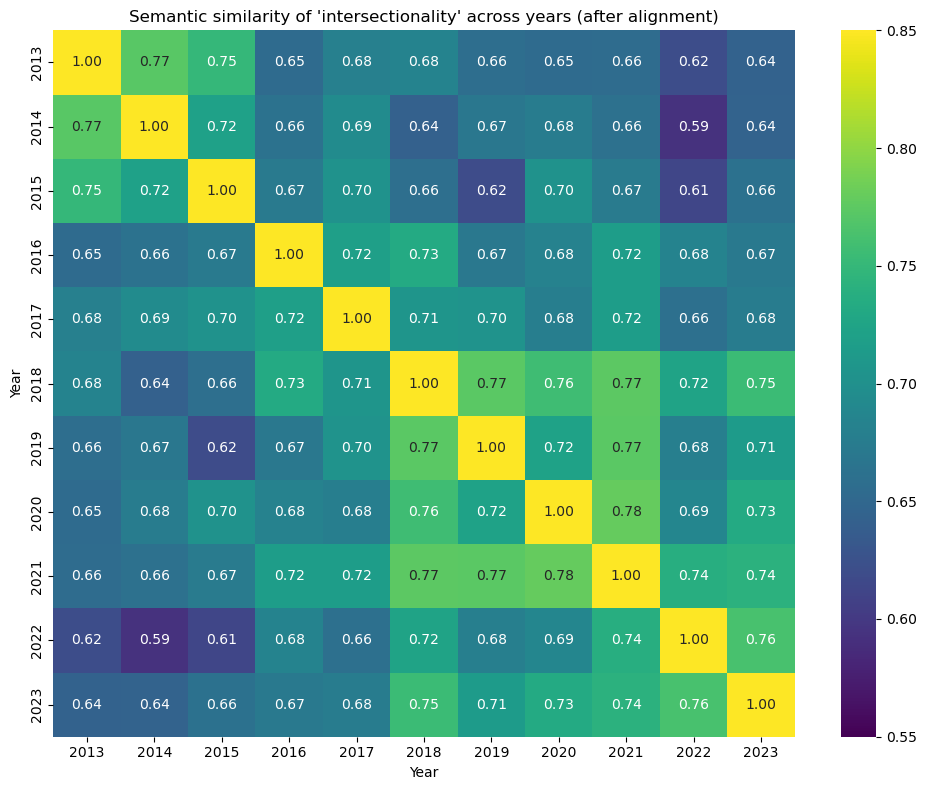

In [52]:
## Visualise pairwise similarities with a heatmap

# Extract aligned vectors for "intersectionality"

years = sorted(aligned_models.keys())
vectors = {}

for year in years:
    try:
        vectors[year] = aligned_models[year]["intersectionality"]
    except KeyError:
        vectors[year] = None  # if missing in vocab

# Build similarity matrix
matrix = np.full((len(years), len(years)), np.nan)

for i, year_i in enumerate(years):
    vec_i = vectors[year_i]
    if vec_i is None:
        continue
    for j, year_j in enumerate(years):
        vec_j = vectors[year_j]
        if vec_j is None:
            continue
        matrix[i, j] = cosine_similarity([vec_i], [vec_j])[0, 0]

# Dataframe and plot heatmap

df_sim = pd.DataFrame(matrix, index=years, columns=years)

plt.figure(figsize=(10, 8))
sns.heatmap(df_sim, annot=True, fmt=".2f", cmap="viridis", vmin=0.55, vmax=0.85)
plt.title("Semantic similarity of 'intersectionality' across years (after alignment)")
plt.xlabel("Year")
plt.ylabel("Year")
plt.tight_layout()
plt.show()


### Dictionary classification

In [55]:
def classify_post_with_counts(text, identity_dict, system_dict):
    text_lower = text.lower()
    tokens = set(re.findall(r"\b\w[\w'-]*\b", text_lower))

    # Identity matching
    matched_identities = []
    identity_categories = set()
    for category, terms in identity_dict.items():
        for term in terms:
            if term in tokens or f" {term} " in f" {text_lower} ":
                matched_identities.append(term)
                identity_categories.add(category)

    # System matching (all terms)
    matched_systems = []
    system_categories = set()
    for category, terms in system_dict.items():
        for term in terms:
            if term in tokens or f" {term} " in f" {text_lower} ":
                matched_systems.append(term)
                system_categories.add(category)


    # Classification label
    has_identity = bool(matched_identities)
    has_system = bool(matched_systems)

    if has_identity and has_system:
        label = "identity + system"
    elif has_identity:
        label = "identity only"
    elif has_system:
        label = "system only"
    else:
        label = "none"

    return pd.Series({
        "label": label,
        "matched_identities": matched_identities,
        "identity_count": len(matched_identities),
        "identity_categories": list(identity_categories),
        "matched_systems": matched_systems,
        "system_count": len(matched_systems),
        "system_categories": list(system_categories),
        
    })


In [56]:
df_new = df.join(df["content_cleaned"].apply(lambda x: classify_post_with_counts(x, identity_axes, systems_of_oppression)))

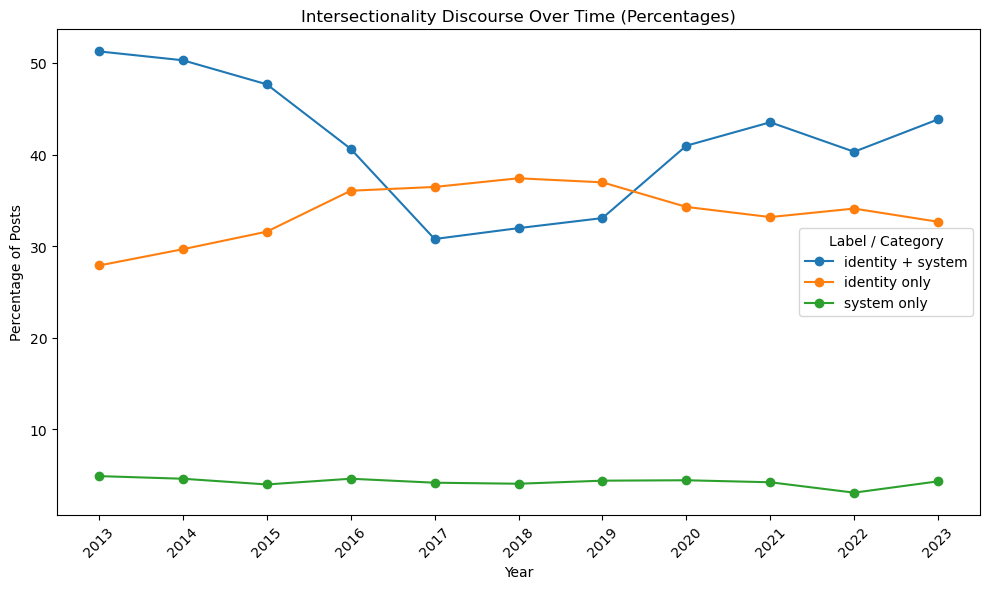

In [57]:
## Visualize with lineplot

# get label percentages per year
label_counts = df_new.groupby(["year", "label"]).size().unstack(fill_value=0)
label_percentages = label_counts.div(label_counts.sum(axis=1), axis=0) * 100

# plot intersectionality label percentages
ax = label_percentages[["identity + system", "identity only", "system only"]].plot(
    kind="line", figsize=(10, 6), marker="o"
)

# all years on the x-axis
years = label_percentages.index.tolist() 
plt.xticks(ticks=years, labels=years, rotation=45) 


# style the plot
plt.title("Intersectionality Discourse Over Time (Percentages)")
plt.ylabel("Percentage of Posts")
plt.xlabel("Year")
plt.legend(title="Label / Category")
plt.tight_layout()
plt.show()
